# 机器学习实验一：bank 数据任务代码框架

本 Notebook 供实验一使用，建议按顺序完成：

1. 读取 `bank_train.csv` 和 `bank_test.csv`
2. 做基础数据检查与预处理
3. 完成任务一：使用 `sklearn` 构建决策树
4. 完成任务二：手写 ID3
5. 完成选做题（可选）
6. 在实验报告中整理结果与分析

> 注意：请根据实验要求补全 `TODO` 部分。


## 0. 导入库


In [1]:
from pathlib import Path
import math

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
)

LABEL_COL = "approve"

## 1. 读取数据


In [2]:
train_path = Path("bank_train.csv")
test_path = Path("bank_test.csv")

if not train_path.exists() or not test_path.exists():
    raise FileNotFoundError("请确认当前文件夹中存在 bank_train.csv 和 bank_test.csv")

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print("训练集大小：", train_df.shape)
print("测试集大小：", test_df.shape)
train_df.head()


训练集大小： (800, 9)
测试集大小： (200, 9)


,nameid,profession,education,house_loan,car_loan,married,child,revenue,approve
0,1,5,1,0,0,1,1,8204,1
1,2,3,1,1,1,0,0,5674,0
2,3,2,3,1,0,1,0,10634,1
3,4,2,2,0,0,0,0,43551,1
4,5,4,2,0,1,0,1,14065,0


## 2. 数据检查与基础预处理

这一步建议完成：

- 查看字段名是否正确
- 检查是否有缺失值
- 查看标签 `approve` 的分布
- 删除编号列 `nameid`


In [3]:
print("训练集字段：", train_df.columns.tolist())
print("测试集字段：", test_df.columns.tolist())

print("\n训练集缺失值统计：")
print(train_df.isnull().sum())

print("\n测试集缺失值统计：")
print(test_df.isnull().sum())

print("\n训练集标签分布：")
print(train_df["approve"].value_counts())

# 删除不参与建模的编号列
train_base = train_df.drop(columns=["nameid"]).copy()
test_base = test_df.drop(columns=["nameid"]).copy()


feature_cols = [c for c in train_base.columns if c != LABEL_COL]

print("\n特征列：", feature_cols)


训练集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']
测试集字段： ['nameid', 'profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue', 'approve']

训练集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

测试集缺失值统计：
nameid        0
profession    0
education     0
house_loan    0
car_loan      0
married       0
child         0
revenue       0
approve       0
dtype: int64

训练集标签分布：
approve
1    518
0    282
Name: count, dtype: int64

特征列： ['profession', 'education', 'house_loan', 'car_loan', 'married', 'child', 'revenue']


# 3. 任务一：使用 sklearn 构建决策树

建议流程：

- 构造 `X / y`
- 从训练集中划分训练子集和验证集
- 至少比较 3 组参数
- 用验证集选择较优参数
- 用测试集做最终评估
- 绘制决策树


## 3.1 构造 `X / y`


In [4]:
# TODO：完成任务一所需的 X / y 构造
# 提示：sklearn 决策树可以直接使用 revenue 的连续数值

X_train_all = train_base[feature_cols]
y_train_all = train_base[LABEL_COL]

X_test = test_base[feature_cols]
y_test = test_base[LABEL_COL]

print("训练集特征形状:", X_train_all.shape)
print("测试集特征形状:", X_test.shape)


训练集特征形状: (800, 7)
测试集特征形状: (200, 7)


## 3.2 划分训练集 / 验证集


In [5]:
# TODO：从训练集内部再划分出验证集
# 提示：可以使用 train_test_split，也可以使用交叉验证

X_train, X_val, y_train, y_val = train_test_split(
    X_train_all, 
    y_train_all, 
    test_size=0.2, 
    random_state=42, 
    stratify=y_train_all
)

print(f"训练子集: {X_train.shape[0]} 条")
print(f"验证集: {X_val.shape[0]} 条")


训练子集: 640 条
验证集: 160 条


## 3.3 参数设置与训练


In [6]:
# TODO：至少记录 3 组参数
# TODO：至少记录 3 组参数
param_list = [
    {"criterion": "gini", "max_depth": 3, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 5, "min_samples_split": 2, "min_samples_leaf": 1},
    {"criterion": "entropy", "max_depth": 10, "min_samples_split": 5, "min_samples_leaf": 2},
]

results = []

for params in param_list:
    # TODO：定义模型, 调用DecisionTreeClassifier
    clf = DecisionTreeClassifier(**params, random_state=42)

    # TODO：训练模型
    clf.fit(X_train, y_train)

    # TODO：在验证集上预测
    y_val_pred = clf.predict(X_val)

    # TODO：计算 Accuracy / Precision / Recall / F1
    # 可参考 accuracy_score、precision_score、recall_score、f1_score
    acc = accuracy_score(y_val, y_val_pred)
    prec = precision_score(y_val, y_val_pred, pos_label=1) # 假设 approve=1 为正类
    rec = recall_score(y_val, y_val_pred, pos_label=1)
    f1 = f1_score(y_val, y_val_pred, pos_label=1)
    
    results.append({
        "params": params,
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1
    })
    print(f"Params: {params}")
    print(f"Val Acc: {acc:.4f}, Prec: {prec:.4f}, Rec: {rec:.4f}, F1: {f1:.4f}\n")

# TODO：显示每组参数的训练结果
results_df = pd.DataFrame(results)
print(results_df)

Params: {'criterion': 'gini', 'max_depth': 3, 'min_samples_split': 2, 'min_samples_leaf': 1}
Val Acc: 0.8063, Prec: 0.7704, Rec: 1.0000, F1: 0.8703

Params: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
Val Acc: 0.8187, Prec: 0.7907, Rec: 0.9808, F1: 0.8755

Params: {'criterion': 'entropy', 'max_depth': 10, 'min_samples_split': 5, 'min_samples_leaf': 2}
Val Acc: 0.7438, Prec: 0.7838, Rec: 0.8365, F1: 0.8093

                                              params  accuracy  precision  \
0  {'criterion': 'gini', 'max_depth': 3, 'min_sam...   0.80625   0.770370   
1  {'criterion': 'entropy', 'max_depth': 5, 'min_...   0.81875   0.790698   
2  {'criterion': 'entropy', 'max_depth': 10, 'min...   0.74375   0.783784   

     recall        f1  
0  1.000000  0.870293  
1  0.980769  0.875536  
2  0.836538  0.809302  


## 3.4 选择参数并在测试集上评估


In [7]:
# TODO：根据验证集结果选择较优参数
# 这里选择 F1-score 最高的模型
best_idx = results_df["f1"].idxmax()
best_params = results_df.loc[best_idx, "params"]
print(f"最佳参数: {best_params}")

# TODO：重新训练最终模型
# 建议使用全部训练数据 (X_train_all) 进行最终训练，以获得更多数据支持
final_clf = DecisionTreeClassifier(**best_params, random_state=42)
final_clf.fit(X_train_all, y_train_all)

# TODO：测试集预测
y_test_pred = final_clf.predict(X_test)

# TODO：计算并打印测试集上的 Accuracy / Precision / Recall / F1
test_acc = accuracy_score(y_test, y_test_pred)
test_prec = precision_score(y_test, y_test_pred, pos_label=1)
test_rec = recall_score(y_test, y_test_pred, pos_label=1)
test_f1 = f1_score(y_test, y_test_pred, pos_label=1)

print("--- 测试集最终评估 ---")
print(f"Accuracy : {test_acc:.4f}")
print(f"Precision: {test_prec:.4f}")
print(f"Recall   : {test_rec:.4f}")
print(f"F1-score : {test_f1:.4f}")

最佳参数: {'criterion': 'entropy', 'max_depth': 5, 'min_samples_split': 2, 'min_samples_leaf': 1}
--- 测试集最终评估 ---
Accuracy : 0.9750
Precision: 1.0000
Recall   : 0.9699
F1-score : 0.9847


## 3.5 混淆矩阵与决策树可视化


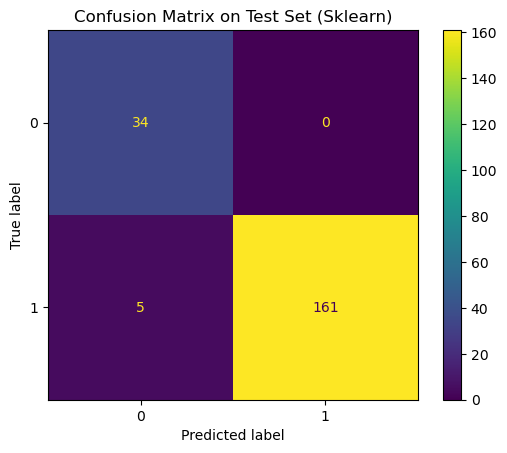

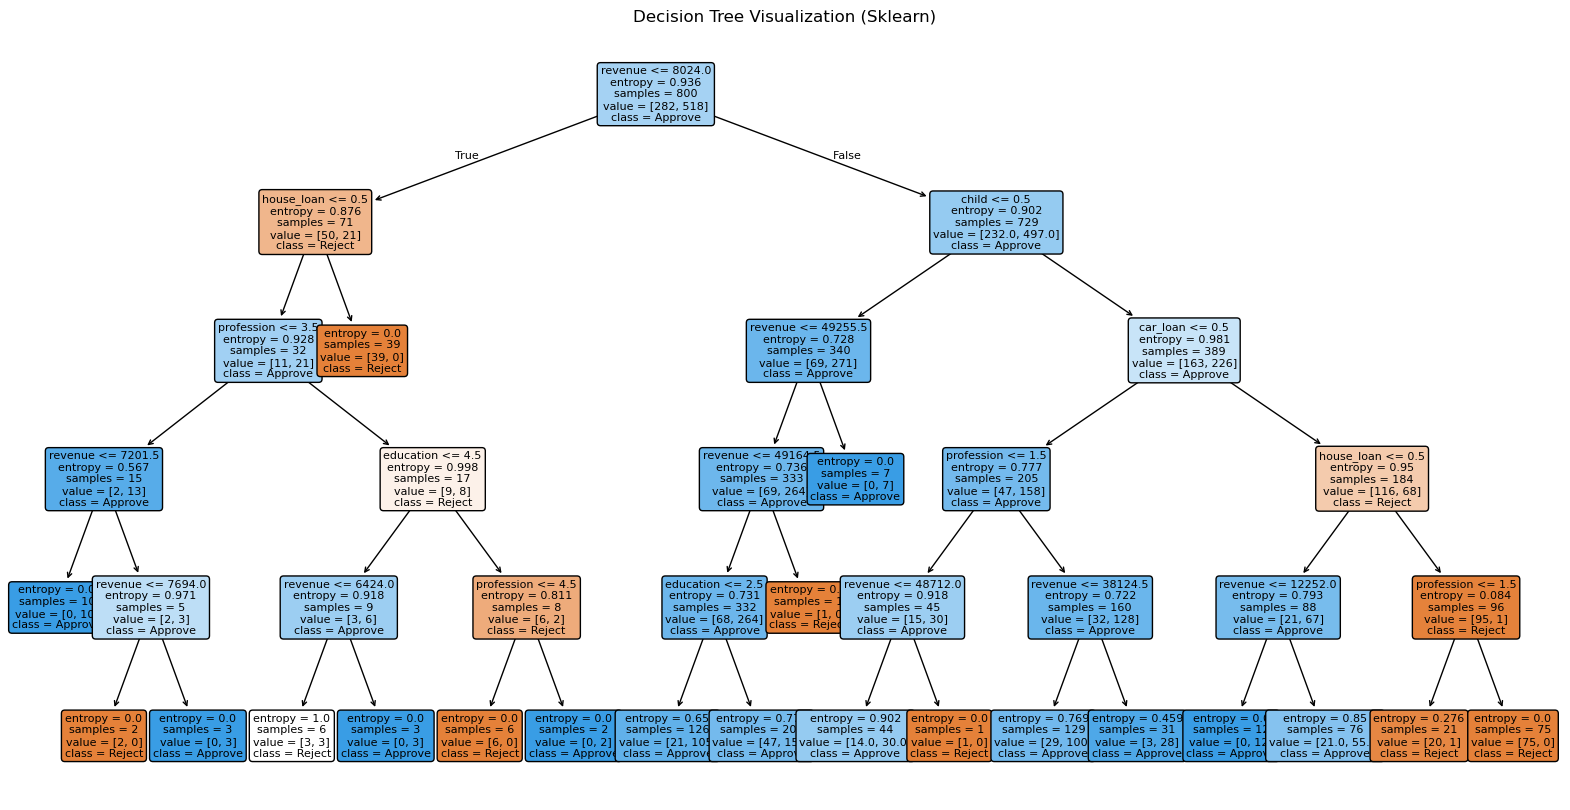

In [8]:
# TODO：绘制混淆矩阵
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1]) # 0: Reject, 1: Approve
disp.plot()
plt.title("Confusion Matrix on Test Set (Sklearn)")
plt.savefig("task1_confusion_matrix.png", dpi=200)
plt.show()

# TODO：绘制决策树，并保存为 png
plt.figure(figsize=(20, 10))
plot_tree(final_clf, 
          feature_names=feature_cols, 
          class_names=["Reject", "Approve"], 
          filled=True, 
          rounded=True,
          fontsize=8)
plt.title("Decision Tree Visualization (Sklearn)")
plt.savefig("task1_tree.png", dpi=200, bbox_inches='tight')
plt.show()

# 4. 任务二：手写 ID3

任务二统一采用：

- 离散特征、多叉树版 ID3
- `revenue` 需要先离散化
- 预测时要处理未见过属性值（fallback）


## 4.1 `revenue` 离散化


In [18]:
# 建议：给任务二单独准备一份数据，避免和任务一互相影响
train_id3 = train_base.copy()
test_id3 = test_base.copy()

# TODO：按实验要求对 revenue 进行离散化
# 定义 bins: (-inf, 10000], (10000, 20000], (20000, 30000], (30000, 40000], (40000, +inf)
bins = [-np.inf, 10000, 20000, 30000, 40000, np.inf]
labels = ['low', 'medium_low', 'medium', 'medium_high', 'high']

# 使用 pd.cut 进行离散化
train_id3["revenue"] = pd.cut(train_id3["revenue"], bins=bins, labels=labels)
test_id3["revenue"] = pd.cut(test_id3["revenue"], bins=bins, labels=labels)

# 确保离散化后没有 NaN (虽然 cut 通常不会产生 NaN 除非有原始 NaN)
print("训练集离散化后 revenue 分布:\n", train_id3["revenue"].value_counts())


训练集离散化后 revenue 分布:
 revenue
medium_low     290
medium         158
low            133
high           115
medium_high    104
Name: count, dtype: int64


## 4.2 核心函数骨架


In [19]:
def calc_entropy(data, label=LABEL_COL):
    # TODO：计算数据集熵
    total = len(data)
    if total == 0:
        return 0
    # 计算各类别的概率
    probs = data[label].value_counts(normalize=True)
    # 熵公式: -sum(p * log2(p))
    # 加小量 1e-9 防止 log(0) 报错
    entropy = -np.sum(probs * np.log2(probs + 1e-9))
    return entropy

def calc_info_gain(data, feature, label=LABEL_COL):
    # TODO：计算某个特征的信息增益
    total_entropy = calc_entropy(data, label)
    total_count = len(data)
    
    # 按特征分组
    grouped = data.groupby(feature)
    weighted_entropy = 0
    
    for name, group in grouped:
        subset_entropy = calc_entropy(group, label)
        weight = len(group) / total_count
        weighted_entropy += weight * subset_entropy
        
    info_gain = total_entropy - weighted_entropy
    return info_gain

def majority_class(data, label=LABEL_COL):
    # TODO：返回当前数据集中的多数类
    if len(data) == 0:
        return None
    return data[label].value_counts().index[0]

def build_tree(data, features, label=LABEL_COL, max_depth=None, current_depth=0):
    # TODO：递归构建多叉决策树
    
    # 1. 如果所有样本属于同一类，返回该类
    # 【重要修复】统一叶子节点结构，class标记为"leaf"，label存具体值
    if len(data[label].unique()) == 1:
        return {"class": "leaf", "label": data[label].iloc[0], "majority": data[label].iloc[0]}
    
    # 2. 如果没有特征可选了，返回多数类
    if len(features) == 0:
        return {"class": "leaf", "label": majority_class(data, label), "majority": majority_class(data, label)}
    
    # 3. 如果达到最大深度，返回多数类 (选做题/预剪枝)
    if max_depth is not None and current_depth >= max_depth:
        return {"class": "leaf", "label": majority_class(data, label), "majority": majority_class(data, label)}

    # 4. 选择最佳特征 (信息增益最大)
    best_feature = None
    max_gain = -1
    
    for feature in features:
        gain = calc_info_gain(data, feature, label)
        if gain > max_gain:
            max_gain = gain
            best_feature = feature
            
    # 如果信息增益为0或很小，直接返回多数类，防止过拟合或死循环
    if max_gain < 1e-9:
         return {"class": "leaf", "label": majority_class(data, label), "majority": majority_class(data, label)}

    # 5. 构建节点
    tree_node = {
        "class": "node",
        "feature": best_feature,
        "majority": majority_class(data, label), # 保存多数类用于 fallback
        "children": {}
    }
    
    # 6. 递归构建子树
    # 获取最佳特征的所有唯一值
    unique_values = data[best_feature].unique()
    
    # 剩余特征
    remaining_features = [f for f in features if f != best_feature]
    
    for value in unique_values:
        # 筛选子集
        subset = data[data[best_feature] == value]
        
        if len(subset) == 0:
            # 如果子集为空，创建一个叶子节点，标记为多数类 (Fallback)
            tree_node["children"][value] = {
                "class": "leaf", 
                "label": majority_class(data, label), 
                "majority": majority_class(data, label)
            }
        else:
            # 递归
            tree_node["children"][value] = build_tree(
                subset, 
                remaining_features, 
                label, 
                max_depth, 
                current_depth + 1
            )
            
    return tree_node

def predict_one(tree, sample):
    # TODO：对单个样本预测
    # 如果 sample 在当前节点上的取值未出现过，则返回 tree["majority"]
    
    # 【重要修复】通过检查是否存在 'feature' 键来判断是否为叶子节点，更加健壮
    if "feature" not in tree:
        return tree["label"]
    
    feature = tree["feature"]
    value = sample[feature]
    
    # 检查该值是否在子节点中存在
    if value in tree["children"]:
        return predict_one(tree["children"][value], sample)
    else:
        # Fallback: 如果测试集中出现了训练集中没见过的特征值，返回该节点的多数类
        return tree["majority"]

def predict(tree, data):
    # TODO：批量预测
    predictions = []
    for index, row in data.iterrows():
        pred = predict_one(tree, row)
        predictions.append(pred)
    return pd.Series(predictions, index=data.index)

## 4.3 模型训练与测试集评估


In [20]:
# TODO：准备任务二的训练特征列表
# 注意：这里使用的是离散化后的数据 train_id3
id3_features = [c for c in train_id3.columns if c != LABEL_COL]

# TODO：构建决策树
# 基础任务可以不传 max_depth，或者传 None
tree = build_tree(train_id3, id3_features, label=LABEL_COL, max_depth=None)

# TODO：在测试集上预测
y_true = test_id3[LABEL_COL]
y_pred = predict(tree, test_id3)

# TODO：手写计算 Accuracy / Precision / Recall / F1
# 建议先展示 TP、TN、FP、FN，再计算指标

# 将结果转换为数值以便计算 (假设 approve=1, reject=0)
# 注意：predict 返回的可能是整数或对象类型，确保比较时类型一致
y_true_vals = y_true.values
y_pred_vals = y_pred.values

# 计算混淆矩阵元素
TP = np.sum((y_true_vals == 1) & (y_pred_vals == 1))
TN = np.sum((y_true_vals == 0) & (y_pred_vals == 0))
FP = np.sum((y_true_vals == 0) & (y_pred_vals == 1))
FN = np.sum((y_true_vals == 1) & (y_pred_vals == 0))

print(f"TP: {TP}, TN: {TN}, FP: {FP}, FN: {FN}")

# 计算指标
acc_id3 = (TP + TN) / (TP + TN + FP + FN) if (TP + TN + FP + FN) > 0 else 0
prec_id3 = TP / (TP + FP) if (TP + FP) > 0 else 0
rec_id3 = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_id3 = 2 * (prec_id3 * rec_id3) / (prec_id3 + rec_id3) if (prec_id3 + rec_id3) > 0 else 0

print("--- ID3 测试集评估 ---")
print(f"Accuracy : {acc_id3:.4f}")
print(f"Precision: {prec_id3:.4f}")
print(f"Recall   : {rec_id3:.4f}")
print(f"F1-score : {f1_id3:.4f}")

TP: 129, TN: 33, FP: 1, FN: 37
--- ID3 测试集评估 ---
Accuracy : 0.8100
Precision: 0.9923
Recall   : 0.7771
F1-score : 0.8716


## 4.4 选做题：预剪枝（可选）

选做题思路：

- 在 4.2 的 `build_tree` 函数中，已经预留了 `max_depth` 和 `current_depth`
- 基础任务中可以保持 `max_depth=None`，表示不限制树的最大深度
- 当 `max_depth is not None` 且 `current_depth >= max_depth` 时停止递归，返回当前多数类
- 递归构建子树时，将 `current_depth + 1` 传入下一层
- 比较 `max_depth = 3, 5, 10, None` 的结果


In [21]:
# TODO：选做题实验位置
# 你可以在这里调用带 max_depth 的 build_tree
# 并比较不同深度下的 Precision / Recall / F1

# 预先计算好 y_true_vals 以便后续使用，如果上面单元格没运行，请确保 y_true 已定义
if 'y_true_vals' not in globals():
    y_true_vals = test_id3[LABEL_COL].values

depths = [3, 5, 10, None]
print("\n--- 预剪枝实验 (ID3) ---")
for d in depths:
    # 构建不同深度的树
    tree_pruned = build_tree(train_id3, id3_features, label=LABEL_COL, max_depth=d)
    
    # 预测
    y_pred_pruned = predict(tree_pruned, test_id3)
    y_p_vals = y_pred_pruned.values
    
    # 计算混淆矩阵元素
    TP_p = np.sum((y_true_vals == 1) & (y_p_vals == 1))
    TN_p = np.sum((y_true_vals == 0) & (y_p_vals == 0))
    FP_p = np.sum((y_true_vals == 0) & (y_p_vals == 1))
    FN_p = np.sum((y_true_vals == 1) & (y_p_vals == 0))
    
    # 计算指标
    acc_p = (TP_p + TN_p) / len(y_true_vals) if len(y_true_vals) > 0 else 0
    prec_p = TP_p / (TP_p + FP_p) if (TP_p + FP_p) > 0 else 0
    rec_p = TP_p / (TP_p + FN_p) if (TP_p + FN_p) > 0 else 0
    f1_p = 2 * (prec_p * rec_p) / (prec_p + rec_p) if (prec_p + rec_p) > 0 else 0
    
    print(f"Max Depth: {str(d):>4} | Acc: {acc_p:.4f} | Prec: {prec_p:.4f} | Rec: {rec_p:.4f} | F1: {f1_p:.4f}")


--- 预剪枝实验 (ID3) ---
Max Depth:    3 | Acc: 0.9750 | Prec: 0.9879 | Rec: 0.9819 | F1: 0.9849
Max Depth:    5 | Acc: 0.8300 | Prec: 0.9853 | Rec: 0.8072 | F1: 0.8874
Max Depth:   10 | Acc: 0.8100 | Prec: 0.9923 | Rec: 0.7771 | F1: 0.8716
Max Depth: None | Acc: 0.8100 | Prec: 0.9923 | Rec: 0.7771 | F1: 0.8716
